# 01 - PPO Expert Training (M1)

**Group members:** Marco De Palma, Em Echeverria, Leah Sarouphin, Juan Jose Rincon Briceño, Matteo Mainetti

PPO expert for `Walker2d-v4` and `Ant-v4`. Expert *training* is expensive (hours) so it is precomputed by `train_expert.py` (commands + runtimes in the README); this notebook loads the submitted checkpoints, **evaluates them live**, and plots the saved learning curves. All seeds are set.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from src import seeding, config
seeding.set_seed(0)            # numpy + torch + python random
DEVICE = config.device()
OUT, MODELS, DATA = ROOT/'outputs', ROOT/'models', ROOT/'data'/'demonstrations'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('precomputed figure not found:', name,
        '- run the corresponding script (see README)')
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok | seeds set | device', DEVICE)

setup ok | seeds set | device mps


## Hyperparameters and rationale (M1)

Base config = SB3 defaults (brief Table 1). Two project-specific choices were decisive and **environment-specific**:

- **Walker2d**: standard config (`n_steps=2048`, `batch=64`, `lr=3e-4` linear) + VecNormalize, 8M steps -> ~6.0k. (The rl-zoo3 tuned profile *failed* here, 1640.)
- **Ant**: rl-zoo3 Optuna profile (`n_steps=512`, `batch=32`, `lr=1.9e-5`, `gamma=0.98`) + VecNormalize, 10M steps -> ~6.3k. (Standard config plateaued ~2850.)

VecNormalize was the common decisive lever. Reproduce:
```
python train_expert.py Walker2d-v4 8000000 4 norm default
python train_expert.py Ant-v4 10000000 1 norm tuned_ant
```

## Evaluate the submitted experts (live) + learning curves

In [2]:
from stable_baselines3 import PPO
rows = []
for env in ['Walker2d-v4', 'Ant-v4']:
    mdir = MODELS/f'ppo_expert_{env}'
    if not (mdir/'best_model.zip').exists():
        print('expert checkpoint missing for', env, '- run train_expert.py'); continue
    model = PPO.load(mdir/'best_model', device='cpu')
    from src import eval as ev
    vn = mdir/'vecnormalize.pkl'
    mean, std = ev.evaluate(model, env, n_episodes=10,
                            vecnorm_path=vn if vn.exists() else None)
    rows.append(dict(env=env, eval_return=round(mean,1), std=round(std,1)))
pd.DataFrame(rows)

/Users/emecheverria/Coding/Reinforcement Learning/GroupProject/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


,env,eval_return,std
0,Walker2d-v4,6203.6,27.5
1,Ant-v4,6123.1,721.6


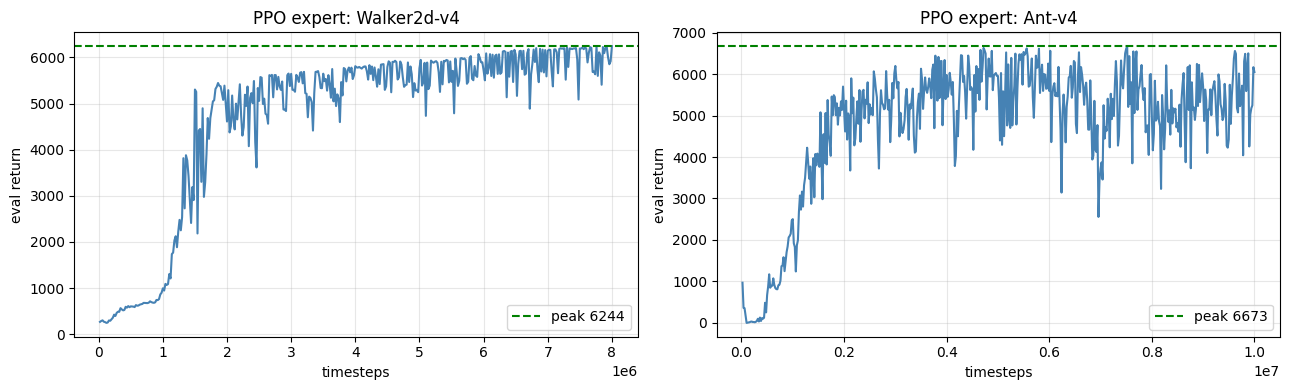

In [3]:
# Saved training curves (eval return vs timesteps).
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, env in zip(axes, ['Walker2d-v4', 'Ant-v4']):
    f = ROOT/'logs'/f'ppo_expert_{env}'/'evaluations.npz'
    if not f.exists(): ax.set_title(f'{env}: run train_expert.py'); continue
    d = np.load(f); r = d['results'].mean(axis=1)
    ax.plot(d['timesteps'], r, color='steelblue')
    ax.axhline(r.max(), color='green', ls='--', label=f'peak {r.max():.0f}')
    ax.set_title(f'PPO expert: {env}'); ax.set_xlabel('timesteps')
    ax.set_ylabel('eval return'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Both experts clear the thresholds with margin (Walker2d > 3000, Ant > 4000).